<a href="https://colab.research.google.com/github/Tookss55/DS/blob/main/Unit7/AmirReganUnit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install preliz
!pip install bambi

In [3]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

Answer1:
You’d use a polynomial when the relationship between the variables isn’t just a straight line. Sometimes the data curves, so and a regular linear model can’t really capture that well. Polynomials let the model bend and fit curves better.

Answer1:

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

Answer2:
 You might not want to use a polynomial because it can make the model too complicated. If you add too many powers, it might start fitting the random noise instead of the real pattern. Also, it can make the model harder to understand and explain. Sometimes a simple straight line works fine, and adding a polynomial just makes things messy for no big reason.

**Task3**:

What's the point of using b splines?

Answer3: B-splines are used to model curved relationships without making one big complicated polynomial. Instead of forcing one equation to fit everything, they break the data into smaller sections and fit smooth curves to each part.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

Answer4: A Gaussian Process is like a way to predict numbers by assuming everything is kind of random but also kinda the same. It uses a normal distribution to guess points. You can plug in one number and it tells you the next number. It only works if the data is really smooth.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.

Answer5:


In [8]:
url_bikes = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/howell.csv'
howell_data = pd.read_csv(url_bikes)

In [10]:
#convert from pandas to numpy array
weight = howell_data["weight"].values
height = howell_data["height"].values[:,None]

In [ ]:
model_1 = bmb.Model("weight ~ poly(height, degree=4)", howell_data)
idata_1 = model_1.fit()

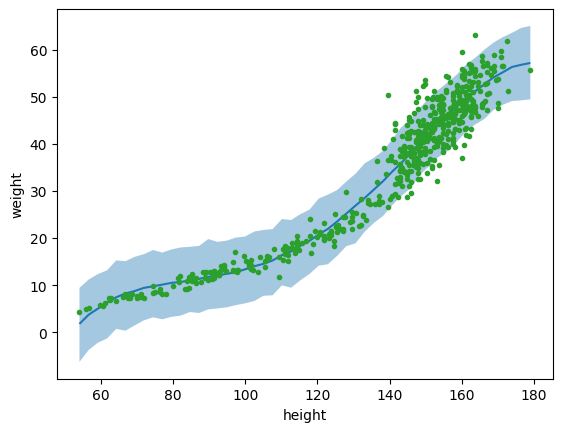

In [13]:
bmb.interpret.plot_predictions(model_1, idata_1, "height", pps=True)
plt.plot(howell_data.height, howell_data.weight, "C2.")

#polynomial:

In [ ]:
num_knots = 6
min_height = howell_data["height"].min()
max_height = howell_data["height"].max()
knots = np.linspace(min_height, max_height, num_knots+2)[1:-1]
model_2 = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell_data)
idata_2 = model_2.fit()

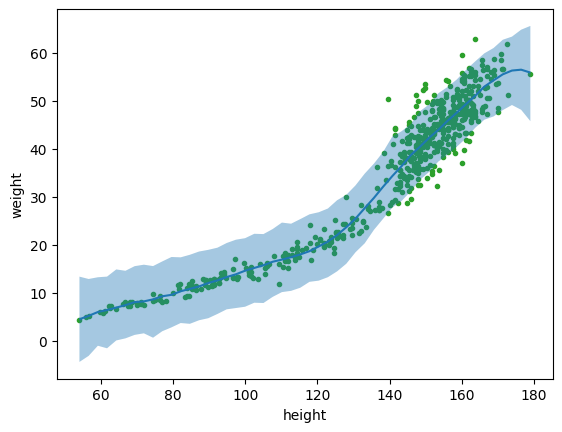

In [17]:
bmb.interpret.plot_predictions(model_2, idata_2, "height", pps= True)
plt.plot(howell_data.height, howell_data.weight, "C2.", zorder=-3)

#bspline:

In [5]:
#code taken from notes
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):


    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))


In [ ]:
#code taken from notes
model_3 = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}

priors = {
    "hsgp(height, m=168, c=8.0)": model_3,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_3 = bmb.Model("weight ~ 0 + hsgp(height, m=168, c=8.0)", howell_data, family="negativebinomial", priors=priors)
idata_3 = model_3.fit()



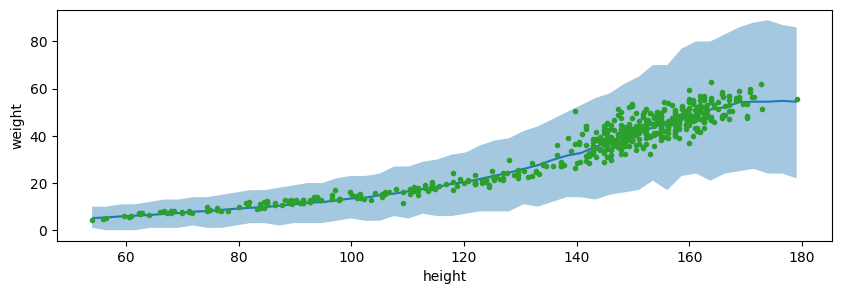

In [23]:
_, ax = bmb.interpret.plot_predictions(model_3, idata_3, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell_data["height"].values, howell_data["weight"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

Answer6:
I learned about scaling functions. They specify the region where the base covariance is active. The base covariance being a value that represents the direction of the linear relationship between two variables.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

Answer7: My favorite graph was the logistical function graph with a gradual changepoint (the one that looks like outer space). It was my favorite because I think it looks the coolest, and I like the idea of representing data with a color gradient.